In [4]:
from CADETProcess.optimization import OptimizationProblem
from CADETProcess.processModel import Inlet, MCT, Outlet
from CADETProcess.optimization import SLSQP, U_NSGA3, Pathos, Joblib, COBYLA, TrustConstr
from CADETProcess.processModel import ComponentSystem,MassActionLaw, LumpedRateModelWithoutPores
from CADETProcess.processModel import FlowSheet
from CADETProcess.processModel import Process
from CADETProcess.simulator import Cadet
from scipy.optimize import minimize


import logging

from IPython import display

from utils import *

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [5]:
df = pd.read_csv('Poplar_02_L1_M3_second_Branch_velocity_change.csv', sep=';')
data = df.to_numpy()
xi = df.columns.values[1:6]
xi = [float(x) for x in xi]

t = data[2:,0]

In [6]:
t

array([ 10.,  15.,  20.,  25.,  30.,  35.,  40.,  45.,  50.,  55.,  60.,
        65.,  70.,  75.,  80.,  85.,  90.,  95., 100., 105., 110., 115.,
       120., 125., 130., 135., 140., 145.])

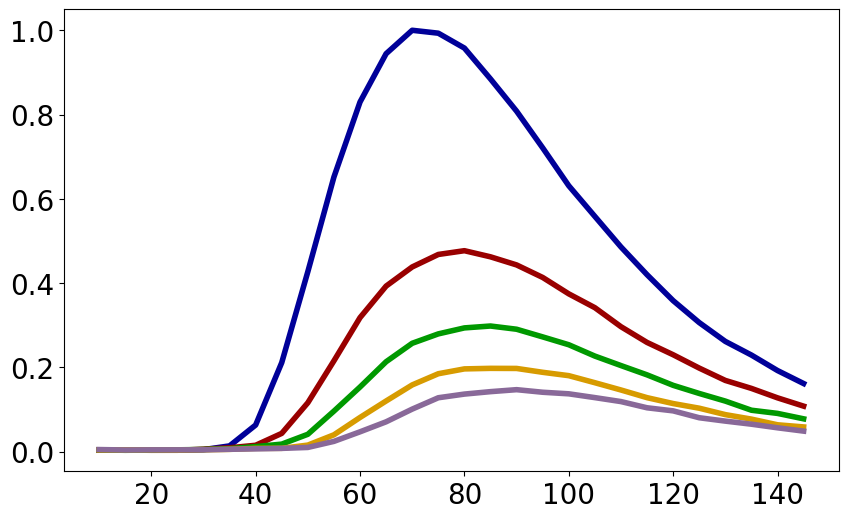

In [7]:
orig_exp_data = data[2:,1:6]
exp_data = data[2:,1:6]*np.exp(-0.00056729782996132*60*t.reshape(len(t),1))
exp_data = exp_data/np.max(exp_data)
plt.plot(t, exp_data)

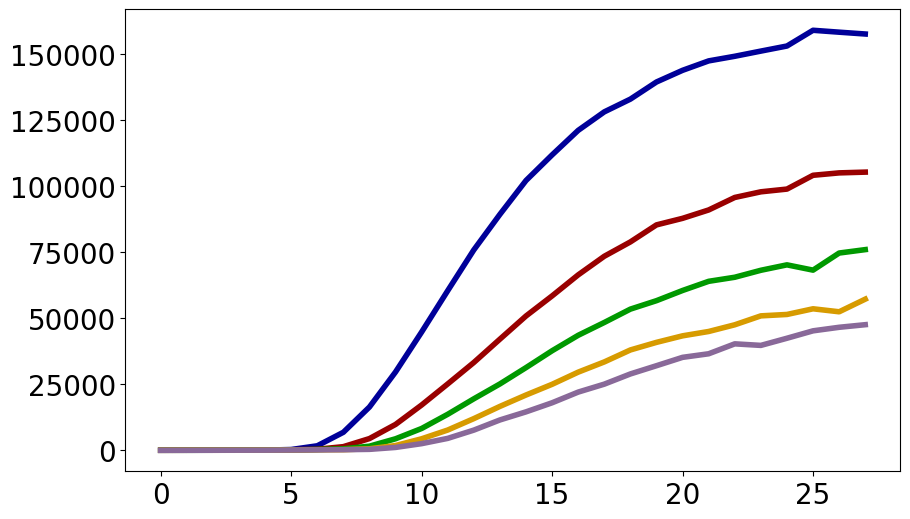

In [8]:
plt.plot(orig_exp_data)

In [9]:
exp_data

array([[0.00353156, 0.00347485, 0.00427754, 0.00426588, 0.00503233],
       [0.00382785, 0.00383701, 0.00334198, 0.00427035, 0.0040181 ],
       [0.00352971, 0.00336319, 0.00388538, 0.00429891, 0.0043515 ],
       [0.00390733, 0.00340101, 0.0043936 , 0.00400689, 0.00435966],
       [0.00488446, 0.00578118, 0.00518296, 0.00463752, 0.00439123],
       [0.01374243, 0.00926707, 0.00709068, 0.00551347, 0.00573681],
       [0.06328174, 0.01518971, 0.01207376, 0.00789904, 0.00669785],
       [0.21135385, 0.04344419, 0.01793356, 0.00798293, 0.00786489],
       [0.42715069, 0.11610697, 0.04129799, 0.01563283, 0.01007102],
       [0.65177101, 0.21555836, 0.09627842, 0.04006326, 0.02446977],
       [0.82973786, 0.31808951, 0.15343443, 0.08119012, 0.04712995],
       [0.94443194, 0.39296428, 0.21346428, 0.12031708, 0.07090274],
       [1.        , 0.43836893, 0.25724122, 0.15841687, 0.10102711],
       [0.9930784 , 0.46800946, 0.27953966, 0.18498883, 0.12798849],
       [0.95776568, 0.47694062, 0.

In [10]:
def setup_process(x):
    
    p_volumetric_flow_rate_const = x[0]
    p_mct1_e12 = x[1]
    p_mct1_e21 = x[2]
    p_mct1_e23 = x[3]
    p_mct2_e12 = x[4]
    p_mct3_e12 = x[5]
    p_mct4_e12 = x[6]
    p_mct2_relA = x[7]
    p_mct3_relA = x[8]
    p_mct4_relA = x[9]
    p_col_dispersion = x[10]

    
  # Initialize the component system and flow sheet
    component_system = ComponentSystem(1)
    mct_flow_sheet = FlowSheet(component_system)

    # Create the units
    inlet = Inlet(component_system, name='inlet')
    leaf = LumpedRateModelWithoutPores(component_system, name='leaf')
    mct1 = MCT(component_system, nchannel=3, name='mct1')
    mct2 = MCT(component_system, nchannel=2, name='mct2')
    mct3 = MCT(component_system, nchannel=2, name='mct3')
    mct4 = MCT(component_system, nchannel=2, name='mct4')
    outlet = Outlet(component_system, name='outlet')

    leaf.discretization.ncol = 20
    mct1.discretization.ncol = 20
    mct2.discretization.ncol = 20
    mct3.discretization.ncol = 20
    mct4.discretization.ncol = 20


    reaction_system = MassActionLaw(component_system)
    reaction_system.add_reaction(
    indices=[0],
    coefficients=[-1],
    k_fwd=0.00056729782996132,
    k_bwd=0,)

    mct1.bulk_reaction_model = reaction_system
    mct2.bulk_reaction_model = reaction_system
    mct3.bulk_reaction_model = reaction_system
    mct4.bulk_reaction_model = reaction_system


    mct_flow_sheet.add_unit(inlet)
    mct_flow_sheet.add_unit(leaf)
    mct_flow_sheet.add_unit(mct1)
    mct_flow_sheet.add_unit(mct2)
    mct_flow_sheet.add_unit(mct3)
    mct_flow_sheet.add_unit(mct4)
    mct_flow_sheet.add_unit(outlet)
    
    v_lrmp = 4e-05

    leaf.total_porosity = 5.54637089e-01
    leaf.length = 1.49024266e-01
    leaf.diameter = x[0]/v_lrmp #np.sqrt(1/np.pi)
    leaf.axial_dispersion = p_col_dispersion

    mct_flow_sheet.add_connection(inlet, leaf)
    mct_flow_sheet.add_connection(leaf, mct1, destination_port = 'channel_0')
    mct_flow_sheet.add_connection(mct1, mct2, origin_port = 'channel_0', destination_port = 'channel_0')
    mct_flow_sheet.add_connection(mct2, mct3, origin_port = 'channel_0', destination_port = 'channel_0')
    mct_flow_sheet.add_connection(mct3, mct4, origin_port = 'channel_0', destination_port = 'channel_0')
    mct_flow_sheet.add_connection(mct4, outlet, origin_port = 'channel_0')

    process = Process(mct_flow_sheet, 'Tracer_Transport')

    mct1.length =  xi[1]/1000
    mct2.length =  xi[2]/1000-xi[1]/1000
    mct3.length =  xi[3]/1000-xi[2]/1000
    mct4.length =  xi[4]/1000-xi[3]/1000


    
    mct1.channel_cross_section_areas = [1,1,1] 
    mct2.channel_cross_section_areas = [p_mct2_relA,p_mct2_relA] 
    mct3.channel_cross_section_areas = [p_mct3_relA,p_mct3_relA] 
    mct4.channel_cross_section_areas = [p_mct4_relA,p_mct4_relA] 

    
    mct1.axial_dispersion = 0# p_mct1_disp
    mct2.axial_dispersion = 0#p_mct2_disp
    mct3.axial_dispersion = 0#p_mct3_disp
    mct4.axial_dispersion = 0#p_mct4_disp

    
    mct1.solution_recorder.write_solution_bulk = 1
    mct2.solution_recorder.write_solution_bulk = 1
    mct3.solution_recorder.write_solution_bulk = 1
    mct4.solution_recorder.write_solution_bulk = 1


    mct1.exchange_matrix = np.array([
                                    [[0.0], [p_mct1_e12], [0.0]],
                                    [[p_mct1_e21], [0.0], [p_mct1_e23]],
                                    [[0.0], [0.0], [0.0]]
                                    ])
    
    mct2.exchange_matrix =np.array([
                                    [[0.0], [p_mct2_e12]],
                                    [[0.0], [0.0]],
                                   
                                    ])
    mct3.exchange_matrix =np.array([
                                    [[0.0], [p_mct3_e12]],
                                    [[0.0], [0.0]],
                                   
                                    ])
    mct4.exchange_matrix =np.array([
                                    [[0.0], [p_mct4_e12]],
                                    [[0.0], [0.0]],
                                   
                                    ])



    process.cycle_time = 60*t[-1]
    
    p_t0 = 1.92818678e+00

    inlet.flow_rate = [p_volumetric_flow_rate_const, 0, 0, 0]

    _ = process.add_event('Base', 'flow_sheet.inlet.c', [0], 0)
    _ = process.add_event('Start', 'flow_sheet.inlet.c', [100], p_t0*600)
    _ = process.add_event('Stop', 'flow_sheet.inlet.c', [0], p_t0*600+60)
    
    return process

In [11]:
xi

[0.0, 14.28070634, 28.32597297, 42.47523083, 56.61385665]

In [12]:
xi[1]/1000,  xi[2]/1000-xi[1]/1000, xi[3]/1000-xi[2]/1000, xi[4]/1000-xi[3]/1000

(0.01428070634, 0.014045266629999999, 0.014149257860000004, 0.01413862582)

In [13]:
6.16752725e-05*6000

0.37005163500000005

In [14]:
1.08112738e-04*60000

6.48676428

In [15]:
# Define min and max values for each parameter

param_bounds = {
    'q': (1e-05, 2e-04),  # log-scaling, volumetric_flow_rate_const
    'mct1_e12': (1e-10, 20),  # log-scaling, mct1_e12
    'mct1_e21': (1e-10, 20),  # log-scaling, mct1_e21
    'mct1_e23': (1e-10, 20),  # log-scaling, mct1_e23
    'mct2_e12': (1e-10, 20),  # log-scaling, mct2_e12
    'mct3_e12': (1e-10, 20),  # log-scaling, mct3_e12
    'mct4_e12': (1e-10, 20),  # log-scaling, mct4_e12
    'relA2': (0.3, 2),  # linear scaling, relA2
    'relA3': (0.3, 2),  # linear scaling, relA3
    'relA4': (0.3, 2),  # linear scaling, relA4
    'col_dispersion': (1e-07, 1e-04),  # log-scaling, col_dispersion
}

  

def analyze_parameters(norm_param_values, param_bounds=param_bounds):
    """
    Analyze parameters and print their names, denormalized values, and normalized values.

    Args:
        norm_param_values (list): Normalized parameter values (0-1 range).
        param_bounds (dict): Dictionary with parameter names as keys and boundary tuples as values.

    Returns:
        None: Prints the analysis.
    """
    print(f"{'Name':<30}{'Denormalized Value':<20}{'Normalized Value':<10}")
    print("-" * 65)

    # Denormalize parameters
    param_values = denormalize_parameters(norm_param_values)

    for i, (name, bounds) in enumerate(param_bounds.items()):
        value = param_values[i]
        norm_param = norm_param_values[i]

        print(f"{name:<30}{value:<20.8e}{norm_param:<10.2f}")



def normalize_parameters(x):
    normalized_x = []
    for i, param in enumerate(param_bounds):
        min_val, max_val = param_bounds[param]
        
        if min_val > 0 and (max_val / min_val) > 100:  # If the range is large, use log scaling
            norm_param = (np.log(x[i]) - np.log(min_val)) / (np.log(max_val) - np.log(min_val))
        else:  # For compact ranges, use min-max scaling
            norm_param = (x[i] - min_val) / (max_val - min_val)
        
        normalized_x.append(norm_param)
    
    return np.array(normalized_x)

def denormalize_parameters(norm_x):
    x = []
    for i, param in enumerate(param_bounds):
        min_val, max_val = param_bounds[param]
        
        if min_val > 0 and (max_val / min_val) > 100:  # Log scaling for large ranges
            param_value = np.exp(norm_x[i] * (np.log(max_val) - np.log(min_val)) + np.log(min_val))
        else:  # Min-max scaling for compact ranges
            param_value = norm_x[i] * (max_val - min_val) + min_val
        
        x.append(param_value)
    
    return np.array(x)

In [16]:
[x / 1000 for x in xi]

[0.0, 0.01428070634, 0.02832597297, 0.04247523083, 0.05661385665]

In [17]:
xi[1]/1000, xi[2]/1000-xi[1]/1000 , xi[3]/1000-xi[2]/1000, xi[4]/1000-xi[3]/1000,xi[-1]/1000-xi[4]/1000

(0.01428070634, 0.014045266629999999, 0.014149257860000004, 0.01413862582, 0.0)

In [18]:
(xi[1]/1000)+(xi[2]/1000-xi[1]/1000)+(xi[3]/1000-xi[2]/1000)+(xi[4]/1000-xi[3]/1000)+(xi[-1]/1000-xi[4]/1000)
    

0.05661385665

In [19]:
lenghts = [x / 1000 for x in xi]

eval_location1 = lenghts[0:1] 
eval_location2 = list(np.array(lenghts[1:2])-lenghts[1])
eval_location3 = list(np.array(lenghts[2:3])-lenghts[2])
eval_location4 = list(np.array(lenghts[3:])-lenghts[3])


eval_location1,eval_location2, eval_location3, eval_location4

([0.0],
 [np.float64(0.0)],
 [np.float64(0.0)],
 [np.float64(0.0), np.float64(0.01413862582)])

In [20]:
(0.01428070634,
 0.014045266629999999,
 0.014149257860000004,
 0.01413862582,
 0.014155704409999997,
 0.013953476179999993,
 0.014223063760000001)

(0.01428070634,
 0.014045266629999999,
 0.014149257860000004,
 0.01413862582,
 0.014155704409999997,
 0.013953476179999993,
 0.014223063760000001)

In [21]:
lenghts[0:1],lenghts[1:3], lenghts[3:4], lenghts[4:]

([0.0], [0.01428070634, 0.02832597297], [0.04247523083], [0.05661385665])

In [22]:
weights = 1 #/ np.mean(exp_data, axis=0)

def mct_obj(x_norm):

    x = denormalize_parameters(x_norm)
    
    process = setup_process(x)
    
    simulation_results = simulator.simulate(process) 
    time_new = np.arange(t[0]*60,t[-1]*60+5*60,5*60)

    mct1 = process.flow_sheet.units[2]
    mct2 = process.flow_sheet.units[3]
    mct3 = process.flow_sheet.units[4]
    mct4 = process.flow_sheet.units[5]

    


    lenghts = [x / 1000 for x in xi]

    eval_location1 = lenghts[0:1] 
    eval_location2 = list(np.array(lenghts[1:2])-lenghts[1])
    eval_location3 = list(np.array(lenghts[2:3])-lenghts[2])
    eval_location4 = list(np.array(lenghts[3:])-lenghts[3])

    cb_mct1 = interpolate_cb_from_simulation_results(simulation_results, mct1, time_new, axial_positions_new = eval_location1)
    calc_data_mct1 = np.atleast_2d(np.sum(cb_mct1, axis=2).squeeze()).T
    
    cb_mct2 = interpolate_cb_from_simulation_results(simulation_results, mct2, time_new, axial_positions_new = eval_location2)
    calc_data_mct2 = np.atleast_2d(np.sum(cb_mct2, axis=2).squeeze()).T

    cb_mct3 = interpolate_cb_from_simulation_results(simulation_results, mct3, time_new, axial_positions_new = eval_location3)
    calc_data_mct3 = np.atleast_2d(np.sum(cb_mct3, axis=2).squeeze()).T

    cb_mct4 = interpolate_cb_from_simulation_results(simulation_results, mct4, time_new, axial_positions_new = eval_location4)
    calc_data_mct4 = np.sum(cb_mct4, axis=2).squeeze()
    



    calc_data = np.hstack((calc_data_mct1,calc_data_mct2,calc_data_mct3,calc_data_mct4))
    calc_data = calc_data/np.max(calc_data)

    residuals = calc_data-exp_data

    weighted_residuals = residuals * weights
    
    SSQ = np.sum(weighted_residuals**2)
    
    plot_fit(time_new, calc_data, exp_data)

    
    print(x, SSQ)

    return SSQ

def mct_obj_res(x_norm):

    x = denormalize_parameters(x_norm)
    
    process = setup_process(x)
    
    simulation_results = simulator.simulate(process) 
    time_new = np.arange(t[0]*60,t[-1]*60+5*60,5*60)


    mct1 = process.flow_sheet.units[2]
    mct2 = process.flow_sheet.units[3]
    mct3 = process.flow_sheet.units[4]
    mct4 = process.flow_sheet.units[5]

    


    lenghts = [x / 1000 for x in xi]

    eval_location1 = lenghts[0:1] 
    eval_location2 = list(np.array(lenghts[1:2])-lenghts[1])
    eval_location3 = list(np.array(lenghts[2:3])-lenghts[2])
    eval_location4 = list(np.array(lenghts[3:])-lenghts[3])

    cb_mct1 = interpolate_cb_from_simulation_results(simulation_results, mct1, time_new, axial_positions_new = eval_location1)
    calc_data_mct1 = np.atleast_2d(np.sum(cb_mct1, axis=2).squeeze()).T
    
    cb_mct2 = interpolate_cb_from_simulation_results(simulation_results, mct2, time_new, axial_positions_new = eval_location2)
    calc_data_mct2 = np.atleast_2d(np.sum(cb_mct2, axis=2).squeeze()).T

    cb_mct3 = interpolate_cb_from_simulation_results(simulation_results, mct3, time_new, axial_positions_new = eval_location3)
    calc_data_mct3 = np.atleast_2d(np.sum(cb_mct3, axis=2).squeeze()).T

    cb_mct4 = interpolate_cb_from_simulation_results(simulation_results, mct4, time_new, axial_positions_new = eval_location4)
    calc_data_mct4 = np.sum(cb_mct4, axis=2).squeeze()
    



    calc_data = np.hstack((calc_data_mct1,calc_data_mct2,calc_data_mct3,calc_data_mct4))
    calc_data = calc_data/np.max(calc_data)
    
    res=(calc_data.ravel()-exp_data.ravel())
    ssq=np.sum(res**2)
    
    plot_fit(time_new, calc_data, exp_data)

    
    print(x, res)

    return res

In [23]:
def plot_fit(time, calc_data, experimental_data):

    display.clear_output(wait=True)

    calc_data = calc_data/np.max(calc_data)
    
    res=np.sum(((calc_data.ravel()-exp_data.ravel())**2).reshape(28,5),axis=1)
    

    fig = plt.figure(figsize=(15,5))
    ax1 = fig.add_subplot(121)
    ax1.plot(time,calc_data[:,0:1], label="mct1", color='k', linewidth=1)
    ax1.plot(time,calc_data[:,1:2], label="mct2", color='r', linewidth=1)
    ax1.plot(time,calc_data[:,2:3], label="mct3", color='b', linewidth=1)
    ax1.plot(time,calc_data[:,3:4], label="mct4", color='g', linewidth=1)
    ax1.plot(time,calc_data[:,4:5], label="mct5", color='y', linewidth=1)
    ax1.plot(time,calc_data[:,6:7], label="mct6", linewidth=1)
    ax1.plot(time,calc_data[:,7:], label="mct7", linewidth=1)
    ax1.plot(time,res, label="res", color='b')
    ax1.plot(time,experimental_data,'.')
    
    #ax1.legend()

    # ax2 = fig.add_subplot(132)

    # ax3 = fig.add_subplot(133)
    # ax3.plot(self.ssq_list, label=ssq)
    # v_text='v:'+str(v)
    # ax3.set_title(v_text)
    # ax3.legend()

    display.display(fig)
    plt.close(fig)
    

In [28]:
simulator = Cadet() 
simulator.use_dll = True
simulator.time_resolution = 60   

# optimization_problem.add_objective(
#     mct_obj,
#     n_objectives=1,
# )


In [29]:
xi

[0.0, 14.28070634, 28.32597297, 42.47523083, 56.61385665]

In [30]:
normalize_parameters([1.92080253e-04, 1.03377242e-02, 4.01628612e-03, 8.76632677e-04,
 4.09094864e-04 ,3.89269484e-04, 2.18478121e-04, 1.44945905e-03,
 3.99507597e+00 ,3.21316671e+00, 4.36618675e+00, 6.62232482e-01,
 2.88712423e-01, 3.55808595e-07, 1.24861405e-01, 1.73904393e+00])

array([ 0.95831712,  0.7091765 ,  0.67284351,  0.61435264,  0.58506384,
        0.58315484,  0.56095842, -0.17561797,  2.1735741 ,  1.71362748,
        2.54670077])

In [31]:
analyze_parameters([0.348445  , 0.67146645, 0.62497946, 0.62451689, 0.64527432,
       0.64669302, 0.64953102, 0.45016873, 0.37919751, 0.19194043,
       0.25133094])

# Parameter 0: ±1.2114252634208134%
# Parameter 1: ±0.16737130949551943%
# Parameter 2: ±1.089811587915188%
# Parameter 3: ±0.4274392639294371%
# Parameter 4: ±0.5753609583974728%
# Parameter 5: ±0.7278256812180686%
# Parameter 6: ±0.9531329176971266%
# Parameter 7: ±7.581347919618608%
# Parameter 8: ±8.294860968237252%
# Parameter 9: ±26.392216361284355%
# Parameter 10: ±0.3335710226393016%

Name                          Denormalized Value  Normalized Value
-----------------------------------------------------------------
q                             7.62045500e-05      0.35      
mct1_e12                      3.87491779e-03      0.67      
mct1_e21                      1.15587701e-03      0.62      
mct1_e23                      1.14204734e-03      0.62      
mct2_e12                      1.96003779e-03      0.65      
mct3_e12                      2.03374837e-03      0.65      
mct4_e12                      2.18962398e-03      0.65      
relA2                         1.06528684e+00      0.45      
relA3                         9.44635767e-01      0.38      
relA4                         6.26298731e-01      0.19      
col_dispersion                5.67535223e-07      0.25      


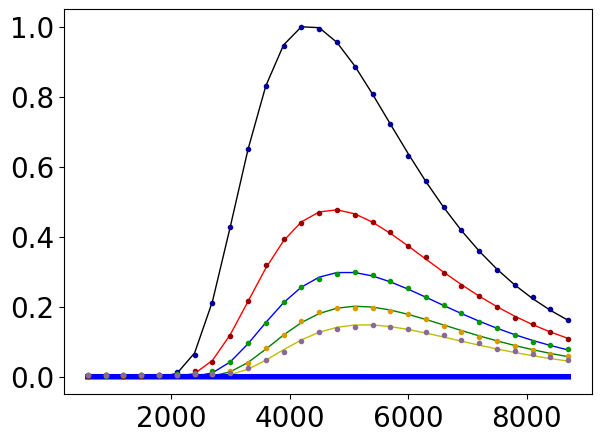

[7.62045500e-05 3.87491779e-03 1.15587701e-03 1.14204734e-03
 1.96003779e-03 2.03374837e-03 2.18962398e-03 1.06528684e+00
 9.44635767e-01 6.26298731e-01 5.67535223e-07] 0.0019954304425654776


np.float64(0.0019954304425654776)

In [32]:
mct_obj([0.348445  , 0.67146645, 0.62497946, 0.62451689, 0.64527432,
       0.64669302, 0.64953102, 0.45016873, 0.37919751, 0.19194043,
       0.25133094])

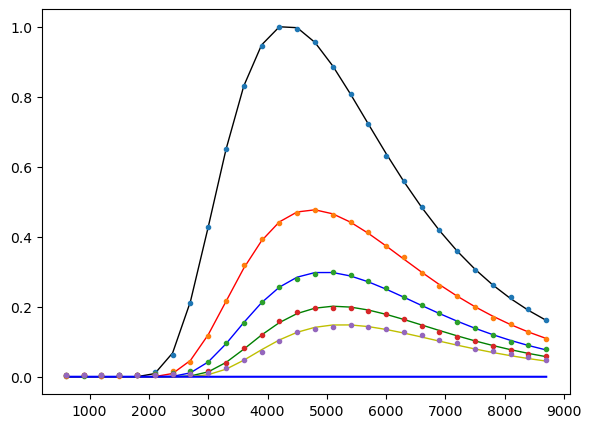

[7.62045502e-05 3.87491756e-03 1.15587699e-03 1.14204725e-03
 1.96003803e-03 2.03374857e-03 2.18962376e-03 1.06528684e+00
 9.44635761e-01 6.26298724e-01 5.67558949e-07] 0.001995430629739904
CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
iters: 149 func evals: 4301 grad evals: 187
||proj grad||_inf: 0.0019477210807294643


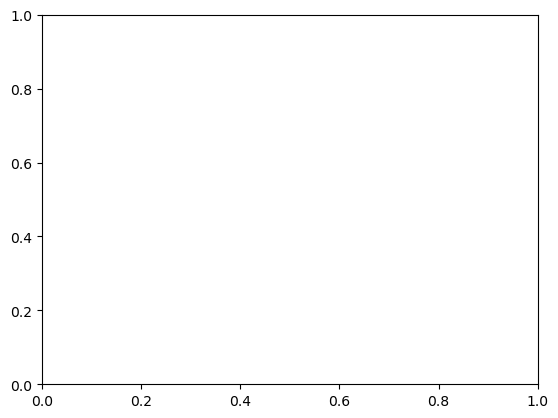

In [231]:
x0 = ([3.12554955e-01, 7.48903224e-01, 8.36423261e-01, 7.64656457e-01,
       6.81753773e-01, 7.04820564e-01, 7.51686204e-01, 4.21154000e-01,
       3.95064495e-01, 1.54957724e-01, 2.48437998e-01])




# Initialize the plot
fig, ax = plt.subplots()

fig.canvas.draw()
display.display(fig)

result_nm = minimize(
    fun=mct_obj,
    x0=x0,
    method='L-BFGS-B',
    jac='3-point',                      # better: pass a callable analytic gradient
    bounds=11 * ((0, 1),),
    options={
        'maxiter': 5000,
        'ftol': 1e-9,                   # function tolerance (strict)
        'gtol': 1e-8,                   # projected gradient tolerance (strict)
        'maxls': 50,                    # more line-search steps if needed
        'eps': 1e-6,                    # finite-diff step (small!)
        # do NOT set 'finite_diff_rel_step' at the same time as 'eps'
    }
)
print(result_nm.message)
print("iters:", result_nm.nit, "func evals:", result_nm.nfev, "grad evals:", result_nm.njev)
print("||proj grad||_inf:", float(np.abs(result_nm.jac).max()))




In [232]:
result_nm.x

array([0.348445  , 0.67146645, 0.62497946, 0.62451689, 0.64527432,
       0.64669302, 0.64953102, 0.45016873, 0.37919751, 0.19194043,
       0.25133094])

In [243]:
import numpy as np
import pandas as pd
from math import sqrt, exp

# =====================
# Denormalized parameters (this run)
# =====================
Q_m3_s = 7.62045500e-05   # volumetric_flow_rate_const  [m^3/s]

# Name                          Denormalized Value  Normalized Value
# -----------------------------------------------------------------
# q                             7.62045500e-05      0.35      
# mct1_e12                      3.87491779e-03      0.67      
# mct1_e21                      1.15587701e-03      0.62      
# mct1_e23                      1.14204734e-03      0.62      
# mct2_e12                      1.96003779e-03      0.65      
# mct3_e12                      2.03374837e-03      0.65      
# mct4_e12                      2.18962398e-03      0.65      
# relA2                         1.06528684e+00      0.45      
# relA3                         9.44635767e-01      0.38      
# relA4                         6.26298731e-01      0.19      
# col_dispersion                5.67535223e-07      0.25       

# Parameter 0: ±1.2114252634208134%
# Parameter 1: ±0.16737130949551943%
# Parameter 2: ±1.089811587915188%
# Parameter 3: ±0.4274392639294371%
# Parameter 4: ±0.5753609583974728%
# Parameter 5: ±0.7278256812180686%
# Parameter 6: ±0.9531329176971266%
# Parameter 7: ±7.581347919618608%
# Parameter 8: ±8.294860968237252%
# Parameter 9: ±26.392216361284355%
# Parameter 10: ±0.3335710226393016%

# relative uncertainties (as fractions, not %)
rel_unc = {
    "Q":        0.012114252634208134,  # Param 0
    "MCT1_e12": 0.0016737130949551943,  # Param 1
    "MCT1_e21": 0.01089811587915188,  # Param 2
    "MCT1_e23": 0.004274392639294371,  # Param 3
    "MCT2_e12": 0.005753609583974728,  # Param 4
    "MCT3_e12": 0.007278256812180686,    # Param 5
    "MCT4_e12": 0.009531329176971266,  # Param 6
    # others only used if you enable interstitial u:
}

# --- cross-sectional areas (m^2) and their relative uncertainties (fraction) ---
# Edit these if your geometry changed.
areas_m2 = {
    "MCT1": 1.0,
    "MCT2": 1.06528684e+00,
    "MCT3":  9.44635767e-01,
    "MCT4": 6.26298731e-01,
}


area_unc_rel = {
    "MCT1": 0.0,
    "MCT2": 0.07581347919618608,
    "MCT3": 0.08294860968237252,
    "MCT4": 0.26392216361284355,
}

# Exchange rates (1/s) → convert to 1/min
rates_s = {
    "MCT1": {"model": "M13", "e12": 3.87491779e-03, "e21": 1.15587701e-03, "e23": 1.14204734e-03},
    "MCT2": {"model": "M02", "e12": 1.96003779e-03},
    "MCT3": {"model": "M02", "e12": 2.03374837e-03},
    "MCT4": {"model": "M02", "e12":  2.18962398e-03},
}
rates_min = {
    k: {**v, **{ek: ev*60.0 for ek, ev in v.items() if ek.startswith("e")}}
    for k, v in rates_s.items()
}

# Velocity mode
use_interstitial_velocity = False
total_porosity = 5.10156571e-01  # only used if interstitial=True

# Axial positions (mm) → 4 units
x_mm = np.array([0.0, 14.28070634, 28.32597297, 42.47523083, 56.61385665])
Ncells = 20

# =====================
# Helpers
# =====================
def velocity_mm_per_min(Q_m3_s, area_m2=1.0, porosity=None):
    """Superficial u = Q/A; interstitial u = Q/(A*ε) if porosity is given."""
    denom = area_m2 if porosity is None else (area_m2 * porosity)
    u_m_s = Q_m3_s / denom
    return u_m_s * 1000.0 * 60.0  # mm/min

def rel_unc_velocity(rel_Q, rel_A=0.0, rel_porosity=0.0, use_interstitial=False):
    """Relative uncertainty for u. If interstitial, include porosity."""
    if use_interstitial:
        return sqrt(rel_Q**2 + rel_A**2 + rel_porosity**2)
    return sqrt(rel_Q**2 + rel_A**2)

# =====================
# Build units
# =====================
units = []
for i, name in enumerate(["MCT1","MCT2","MCT3","MCT4"]):
    L_mm = float(x_mm[i+1] - x_mm[i])
    dx_mm = L_mm / Ncells
    units.append({
        "name": name,
        "L_mm": L_mm,
        "dx_mm": dx_mm,
        "area_m2": areas_m2[name],
        "area_rel_unc": area_unc_rel[name],
    })

# =====================
# Core loop
# =====================
rows = []
for u in units:
    name = u["name"]
    L_mm = u["L_mm"]
    dx_mm = u["dx_mm"]
    A = u["area_m2"]
    rel_A = u["area_rel_unc"]

    # Velocity & its relative uncertainty (per unit, depends on A)
    if use_interstitial_velocity:
        u_mm_min = velocity_mm_per_min(Q_m3_s, A, total_porosity)
        u_rel = rel_unc_velocity(rel_unc["Q"], rel_A, rel_unc["porosity"], True)
    else:
        u_mm_min = velocity_mm_per_min(Q_m3_s, A, None)
        u_rel = rel_unc_velocity(rel_unc["Q"], rel_A, 0.0, False)

    # Theta [1/mm] and its relative uncertainty
    p = rates_min[name]
    if p["model"] == "M13":
        e12, e21, e23 = p["e12"], p["e21"], p["e23"]
        theta = (e12 * e23) / (u_mm_min * (e21 + e23))

        # rel uncertainty parts for M13
        rel_e12 = rel_unc["MCT1_e12"]
        rel_e21 = rel_unc["MCT1_e21"]
        rel_e23 = rel_unc["MCT1_e23"]
        sigma_sum = sqrt((rel_e21*e21)**2 + (rel_e23*e23)**2)
        rel_sum = sigma_sum / (e21 + e23)

        rel_theta = sqrt(rel_e12**2 + rel_e23**2 + u_rel**2 + rel_sum**2)
    else:  # M02
        e12 = p["e12"]
        theta = e12 / u_mm_min
        rel_theta = sqrt(rel_unc[f"{name}_e12"]**2 + u_rel**2)

    # === Loss metrics ===
    L_cell = 1.0 - exp(-theta * dx_mm)
    sigma_L_cell = exp(-theta * dx_mm) * dx_mm * (theta * rel_theta)

    L_per_mm_avg = L_cell / dx_mm
    sigma_L_per_mm_avg = sigma_L_cell / dx_mm

    L_total_cont = 1.0 - exp(-theta * L_mm)
    sigma_L_total_cont = exp(-theta * L_mm) * L_mm * (theta * rel_theta)

    L_total_disc = 1.0 - (1.0 - L_cell)**Ncells
    d_disc_d_Lcell = Ncells * (1.0 - L_cell)**(Ncells - 1)
    sigma_L_total_disc = d_disc_d_Lcell * sigma_L_cell

    rows.append({
        "Unit": name,
        "Area_m2": A,
        "Area_rel_unc_%": rel_A * 100.0,

        "Length_mm": L_mm,
        "Cell_length_mm": dx_mm,

        "Velocity_mm_per_min": u_mm_min,
        "Velocity_rel_unc_%": u_rel * 100.0,

        "Theta_1_per_mm": theta,
        "Theta_rel_unc_%": rel_theta * 100.0,

        "Loss_per_cell_frac": L_cell,
        "Loss_per_cell_unc_abs": sigma_L_cell,

        "Loss_per_mm_avg_frac": L_per_mm_avg,
        "Loss_per_mm_avg_unc_abs": sigma_L_per_mm_avg,

        "Total_loss_cont_frac": L_total_cont,
        "Total_loss_cont_unc_abs": sigma_L_total_cont,
        "Total_loss_disc_frac": L_total_disc,
        "Total_loss_disc_unc_abs": sigma_L_total_disc,
    })

df = pd.DataFrame(rows).set_index("Unit")

# ---- % columns & relative-uncertainty columns ----
df["Loss_per_cell_%"] = 100.0 * df["Loss_per_cell_frac"]
df["Loss_per_cell_unc_abs_%"] = 100.0 * df["Loss_per_cell_unc_abs"]
df["Loss_per_cell_rel_unc_%"] = 100.0 * (df["Loss_per_cell_unc_abs"] / np.maximum(df["Loss_per_cell_frac"], 1e-300))

df["Loss_per_mm_avg_%"] = 100.0 * df["Loss_per_mm_avg_frac"]
df["Loss_per_mm_avg_unc_abs_%"] = 100.0 * df["Loss_per_mm_avg_unc_abs"]
df["Loss_per_mm_avg_rel_unc_%"] = 100.0 * (df["Loss_per_mm_avg_unc_abs"] / np.maximum(df["Loss_per_mm_avg_frac"], 1e-300))

df["Total_loss_cont_%"] = 100.0 * df["Total_loss_cont_frac"]
df["Total_loss_cont_unc_abs_%"] = 100.0 * df["Total_loss_cont_unc_abs"]
df["Total_loss_cont_rel_unc_%"] = 100.0 * (df["Total_loss_cont_unc_abs"] / np.maximum(df["Total_loss_cont_frac"], 1e-300))

df["Total_loss_disc_%"] = 100.0 * df["Total_loss_disc_frac"]
df["Total_loss_disc_unc_abs_%"] = 100.0 * df["Total_loss_disc_unc_abs"]
df["Total_loss_disc_rel_unc_%"] = 100.0 * (df["Total_loss_disc_unc_abs"] / np.maximum(df["Total_loss_disc_frac"], 1e-300))

# =====================
# Select columns to display (toggle sections here)
# =====================
SHOW_THETA  = False
SHOW_TOTALS = False

order = [
    "Area_m2","Area_rel_unc_%",
    "Length_mm","Cell_length_mm",
    "Velocity_mm_per_min","Velocity_rel_unc_%",
    *(["Theta_1_per_mm","Theta_rel_unc_%"] if SHOW_THETA else []),
    "Loss_per_cell_frac","Loss_per_cell_%","Loss_per_cell_unc_abs_%","Loss_per_cell_rel_unc_%",
    "Loss_per_mm_avg_frac","Loss_per_mm_avg_%","Loss_per_mm_avg_unc_abs_%","Loss_per_mm_avg_rel_unc_%",
    *([
        "Total_loss_cont_frac","Total_loss_cont_%","Total_loss_cont_unc_abs_%","Total_loss_cont_rel_unc_%",
        "Total_loss_disc_frac","Total_loss_disc_%","Total_loss_disc_unc_abs_%","Total_loss_disc_rel_unc_%"
      ] if SHOW_TOTALS else [])
]

df = df[[c for c in order if c in df.columns]].copy()

# ---- rounding ----
round_map = {
    "Area_m2": 6, "Area_rel_unc_%": 3,
    "Length_mm": 4, "Cell_length_mm": 4,
    "Velocity_mm_per_min": 4, "Velocity_rel_unc_%": 3,
    "Theta_1_per_mm": 6, "Theta_rel_unc_%": 3,
    "Loss_per_cell_frac": 6, "Loss_per_cell_%": 4, "Loss_per_cell_unc_abs_%": 4, "Loss_per_cell_rel_unc_%": 3,
    "Loss_per_mm_avg_frac": 6, "Loss_per_mm_avg_%": 4, "Loss_per_mm_avg_unc_abs_%": 4, "Loss_per_mm_avg_rel_unc_%": 3,
    "Total_loss_cont_frac": 6, "Total_loss_cont_%": 4, "Total_loss_cont_unc_abs_%": 4, "Total_loss_cont_rel_unc_%": 3,
    "Total_loss_disc_frac": 6, "Total_loss_disc_%": 4, "Total_loss_disc_unc_abs_%": 4, "Total_loss_disc_rel_unc_%": 3,
}
for c, r in round_map.items():
    if c in df.columns:
        df[c] = df[c].round(r)

print(df)




       Area_m2  Area_rel_unc_%  Length_mm  Cell_length_mm  \
Unit                                                        
MCT1  1.000000           0.000    14.2807          0.7140   
MCT2  1.065287           7.581    14.0453          0.7023   
MCT3  0.944636           8.295    14.1493          0.7075   
MCT4  0.626299          26.392    14.1386          0.7069   

      Velocity_mm_per_min  Velocity_rel_unc_%  Loss_per_cell_frac  \
Unit                                                                
MCT1               4.5723               1.211            0.017883   
MCT2               4.2921               7.678            0.019058   
MCT3               4.8402               8.383            0.017677   
MCT4               7.3005              26.420            0.012641   

      Loss_per_cell_%  Loss_per_cell_unc_abs_%  Loss_per_cell_rel_unc_%  \
Unit                                                                      
MCT1           1.7883                   0.0252                    1.

In [35]:
def plot_pretty(x_norm):

    x = denormalize_parameters(x_norm)
    
    process = setup_process(x)
    
    simulation_results = simulator.simulate(process) 
    time_new = np.arange(t[0]*60,t[-1]*60+5*60,5*60)

    mct1 = process.flow_sheet.units[2]
    mct2 = process.flow_sheet.units[3]
    mct3 = process.flow_sheet.units[4]
    mct4 = process.flow_sheet.units[5]

    


    lenghts = [x / 1000 for x in xi]

    eval_location1 = lenghts[0:1] 
    eval_location2 = list(np.array(lenghts[1:2])-lenghts[1])
    eval_location3 = list(np.array(lenghts[2:3])-lenghts[2])
    eval_location4 = list(np.array(lenghts[3:])-lenghts[3])

    cb_mct1 = interpolate_cb_from_simulation_results(simulation_results, mct1, time_new, axial_positions_new = eval_location1)
    calc_data_mct1 = np.atleast_2d(np.sum(cb_mct1, axis=2).squeeze()).T
    
    cb_mct2 = interpolate_cb_from_simulation_results(simulation_results, mct2, time_new, axial_positions_new = eval_location2)
    calc_data_mct2 = np.atleast_2d(np.sum(cb_mct2, axis=2).squeeze()).T

    cb_mct3 = interpolate_cb_from_simulation_results(simulation_results, mct3, time_new, axial_positions_new = eval_location3)
    calc_data_mct3 = np.atleast_2d(np.sum(cb_mct3, axis=2).squeeze()).T

    cb_mct4 = interpolate_cb_from_simulation_results(simulation_results, mct4, time_new, axial_positions_new = eval_location4)
    calc_data_mct4 = np.sum(cb_mct4, axis=2).squeeze()
    



    calc_data = np.hstack((calc_data_mct1,calc_data_mct2,calc_data_mct3,calc_data_mct4))
    calc_data = calc_data/np.max(calc_data)

    #plt.plot(t,calc_data, label="mct1", linewidth=1)
    #plt.gca().set_prop_cycle(None)
    
    plt.style.use('default')
    
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)


    plt.plot(t,calc_data[:,0:1], label="ROI 1", color=plt.rcParams['axes.prop_cycle'].by_key()['color'][0], linewidth=1.5)
    plt.plot(t,calc_data[:,1:2], label="ROI 2", color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1], linewidth=1.5)
    plt.plot(t,calc_data[:,2:3], label="ROI 3", color=plt.rcParams['axes.prop_cycle'].by_key()['color'][2], linewidth=1.5)
    plt.plot(t,calc_data[:,3:4], label="ROI 4", color=plt.rcParams['axes.prop_cycle'].by_key()['color'][3], linewidth=1.5)
    plt.plot(t,calc_data[:,4:], label="ROI 5", color=plt.rcParams['axes.prop_cycle'].by_key()['color'][4], linewidth=1.5)
    
    plt.plot(t,exp_data[:,0:1],'.',color=plt.rcParams['axes.prop_cycle'].by_key()['color'][0], markersize=8)
    plt.plot(t,exp_data[:,1:2],'.',color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1], markersize=8)
    plt.plot(t,exp_data[:,2:3],'.',color=plt.rcParams['axes.prop_cycle'].by_key()['color'][2], markersize=8)
    plt.plot(t,exp_data[:,3:4],'.',color=plt.rcParams['axes.prop_cycle'].by_key()['color'][3], markersize=8)
    plt.plot(t,exp_data[:,4:],'.',color=plt.rcParams['axes.prop_cycle'].by_key()['color'][4], markersize=8)

    # Remove duplicate labels
    handles, labels = plt.gca().get_legend_handles_labels()
    unique_handles_labels = dict(zip(labels, handles))  # Remove duplicates
    


    # Add legend with unique labels
    plt.legend(unique_handles_labels.values(), unique_handles_labels.keys(),fontsize=12)
    
    plt.xlabel("Time [min]", fontsize=16)
    plt.ylabel("Activity [a.u.]", fontsize=16)
    plt.savefig("storage_change_mct_area.pdf", format="pdf")  

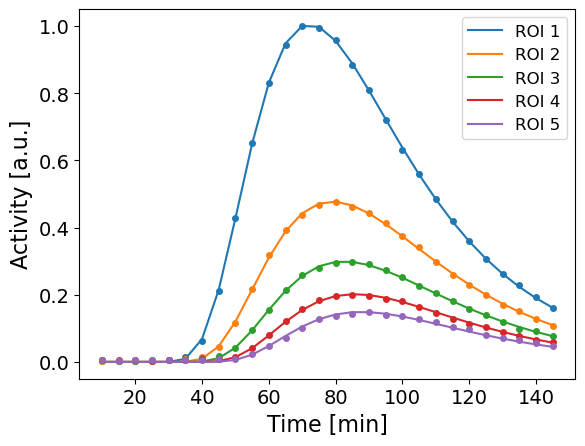

In [36]:
plot_pretty([0.348445  , 0.67146645, 0.62497946, 0.62451689, 0.64527432,
       0.64669302, 0.64953102, 0.45016873, 0.37919751, 0.19194043,
       0.25133094])

In [3]:
x_best_fit = ([0.348445  , 0.67146645, 0.62497946, 0.62451689, 0.64527432,
       0.64669302, 0.64953102, 0.45016873, 0.37919751, 0.19194043,
       0.25133094])

def compute_jacobian(f, x, eps=None):
    """Computes numerical Jacobian using central difference with adaptive epsilon."""
    x = np.asarray(x)
    n_params = len(x)
    f_x = np.asarray(f(x)).ravel()
    n_outputs = len(f_x)
    J = np.zeros((n_outputs, n_params))

    if eps is None:
        eps = np.sqrt(np.finfo(float).eps) * np.maximum(1.0, np.abs(x))

    for i in range(n_params):
        x_step = np.zeros_like(x)
        x_step[i] = eps[i]

        f_plus = np.asarray(f(x + x_step)).ravel()
        f_minus = np.asarray(f(x - x_step)).ravel()

        J[:, i] = (f_plus - f_minus) / (2 * eps[i])

    return J



# Compute the Jacobian
J = compute_jacobian(mct_obj_res, x_best_fit)

# Step 3: Compute the covariance matrix
JTJ_inv = np.linalg.pinv(J.T @ J)
sigma_squared = np.var(mct_obj_res(x_best_fit))  # Estimate variance of residuals
C = JTJ_inv * sigma_squared  # Covariance matrix

# Step 4: Compute parameter uncertainties
param_uncertainties = np.sqrt(np.abs(np.diag(C)))  # Extract uncertainties
rel_param_uncertanties = param_uncertainties / np.abs(x_best_fit)

# Print results
for i, uncertainty in enumerate(rel_param_uncertanties):
    print(f"Parameter {i}: ±{uncertainty*100}%")

NameError: name 'mct_obj_res' is not defined